# Notebook code từ đầu toàn bộ pipeline dự án:


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [5]:
cur = Path.cwd()
candidate = [cur, cur.parent]
pjroot = None
for candi in candidate:
    if (candi / "data" / "raw").exists() and (candi / "src").exists():
        pjroot = candi
        break
if not pjroot:
    raise FileNotFoundError("Could not find project root. Please ensure that the project has a 'data/raw' directory and a 'src' directory.")

data_dir = pjroot / "data" / "raw"

imdbpath = data_dir / "imdb" / "IMDB_dataset.csv"
sstpath = data_dir / "sst" / "train.csv"

In [16]:
#imdb
df1 = pd.read_csv(imdbpath)
#Sử dụng lowermap để có thể truy cập các cột bằng cách sử dụng tên cột đã được chuyển thành chữ thường, giúp tránh lỗi do sự khác biệt về định dạng tên cột.
lowermap1 = {column: column.lower() for column in df1.columns}
#text_candi và label_candi là hai danh sách chứa các từ khóa có thể xuất hiện trong tên cột của dataframe, giúp xác định cột nào chứa văn bản và cột nào chứa nhãn.
text_candi1 = ["review", "text", "content", "sentence","comment"]
label_candi1 = ["sentiment", "label", "target", "class", "polarity"]
#text_col và label_col được xác định bằng cách tìm kiếm trong lowermap để xem nếu có bất kỳ cột nào chứa các từ khóa trong text_candi hoặc label_candi. Nếu không tìm thấy, nó sẽ mặc định sử dụng cột đầu tiên cho văn bản và cột cuối cùng cho nhãn.
text_col1 = next((lowermap1[candidate] for candidate in text_candi1 if candidate in lowermap1), df1.columns[0])
label_col1 = next((lowermap1[candidate] for candidate in label_candi1 if candidate in lowermap1), df1.columns[-1])
work1 = df1[[text_col1, label_col1]].copy()
row1 = len(work1)
labels1 = work1[label_col1].unique()
avg_tokens1 = work1[text_col1].apply(lambda x: len(str(x).split())).mean()
median_tokens1 = work1[text_col1].apply(lambda x: len(str(x).split())).median()
mintoken1 = work1[text_col1].apply(lambda x: len(str(x).split())).min()
maxtoken1 = work1[text_col1].apply(lambda x: len(str(x).split())).max()
print(f"Dataset: {imdbpath.name}")
print(f"Rows: {row1}")
print(f"Labels: {list(labels1)}")
print(f"Average Tokens: {avg_tokens1}")
print(f"Median Tokens: {median_tokens1}")
print(f"Min Tokens: {mintoken1}")
print(f"Max Tokens: {maxtoken1}")




Dataset: IMDB_dataset.csv
Rows: 50000
Labels: ['positive', 'negative']
Average Tokens: 231.15694
Median Tokens: 173.0
Min Tokens: 4
Max Tokens: 2470


In [17]:
df2 = pd.read_csv(sstpath)
#Sử dụng lowermap để có thể truy cập các cột bằng cách sử dụng tên cột đã được chuyển thành chữ thường, giúp tránh lỗi do sự khác biệt về định dạng tên cột.
lowermap2 = {column: column.lower() for column in df2.columns}
#text_candi và label_candi là hai danh sách chứa các từ khóa có thể xuất hiện trong tên cột của dataframe, giúp xác định cột nào chứa văn bản và cột nào chứa nhãn.
text_candi2 = ["review", "text", "content", "sentence","comment"]
label_candi2 = ["sentiment", "label", "target", "class", "polarity"]
#text_col và label_col được xác định bằng cách tìm kiếm trong lowermap để xem nếu có bất kỳ cột nào chứa các từ khóa trong text_candi hoặc label_candi. Nếu không tìm thấy, nó sẽ mặc định sử dụng cột đầu tiên cho văn bản và cột cuối cùng cho nhãn.
text_col2 = next((lowermap2[candidate] for candidate in text_candi2 if candidate in lowermap2), df2.columns[0])
label_col2 = next((lowermap2[candidate] for candidate in label_candi2 if candidate in lowermap2), df2.columns[-1])
work2 = df2[[text_col2, label_col2]].copy()
row2 = len(work2)
labels2 = work2[label_col2].unique()
avg_tokens2 = work2[text_col2].apply(lambda x: len(str(x).split())).mean()
median_tokens2 = work2[text_col2].apply(lambda x: len(str(x).split())).median()
mintoken2 = work2[text_col2].apply(lambda x: len(str(x).split())).min()
maxtoken2 = work2[text_col2].apply(lambda x: len(str(x).split())).max()
print(f"Dataset: {sstpath.name}")
print(f"Rows: {row2}")
print(f"Labels: {list(labels2)}")
print(f"Average Tokens: {avg_tokens2}")
print(f"Median Tokens: {median_tokens2}")
print(f"Min Tokens: {mintoken2}")
print(f"Max Tokens: {maxtoken2}")


Dataset: train.csv
Rows: 67349
Labels: [np.int64(0), np.int64(1)]
Average Tokens: 10.409553222765
Median Tokens: 8.0
Min Tokens: 2
Max Tokens: 53


In [20]:
print('\nIMDB preview:')
display(work1.head(5))

print('\nSST preview:')
display(work2.head(5))



IMDB preview:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



SST preview:


,sentence,target
0,b'for the uninitiated plays better on video wi...,0
1,b'like a giant commercial for universal studio...,0
2,b'company once again dazzle and delight us ',1
3,"b""'s no surprise that as a director washington...",1
4,"b', this cross-cultural soap opera is painfull...",0


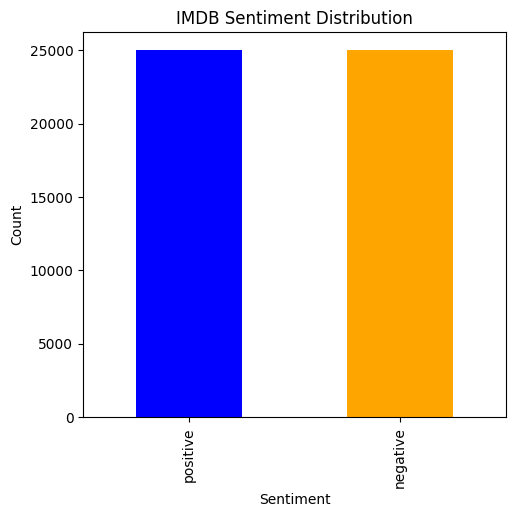

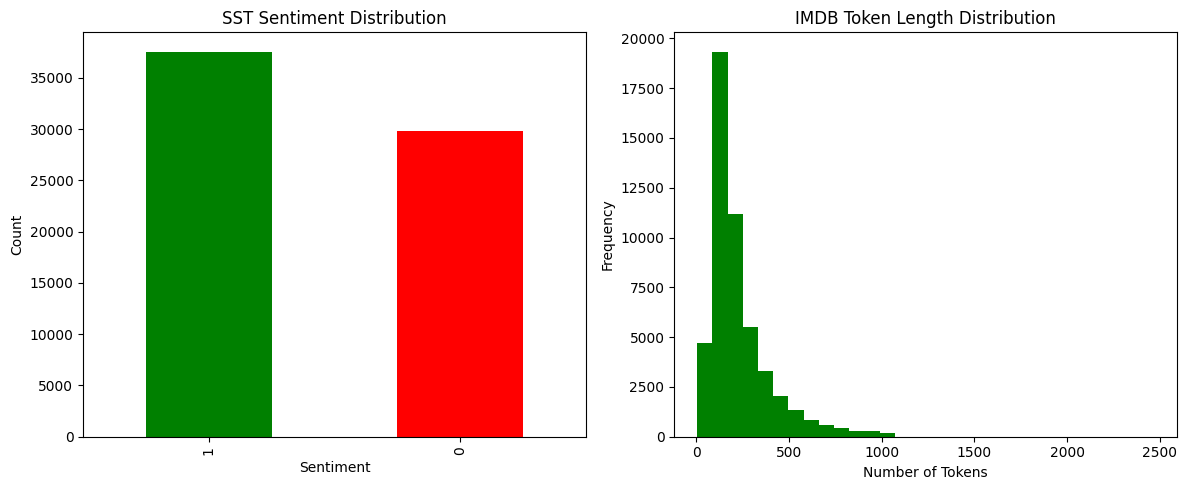

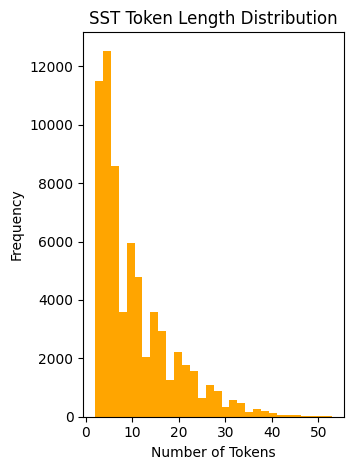

In [24]:
#biểu đồ phân bố negative và positive trong hai dataset bằng histogram
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
work1[label_col1].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('IMDB Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
work2[label_col2].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('SST Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
#biểu đồ phân bố độ dài token trong hai dataset bằng histogram
plt.subplot(1, 2, 2)
work1[text_col1].apply(lambda x: len(str(x).split())).plot(kind='hist', bins=30, color='green')
plt.title('IMDB Token Length Distribution')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.subplot(1, 2, 2)
work2[text_col2].apply(lambda x: len(str(x).split())).plot(kind='hist', bins=30, color='orange')
plt.title('SST Token Length Distribution')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [25]:
#tiền xử lý text
def cleanNtokenize(text):
    # Chuyển đổi văn bản thành chữ thường
    text = text.lower()
    # Loại bỏ dấu câu và ký tự đặc biệt
    text = ''.join(char for char in text if char.isalnum() or char.isspace())
    # Loại bỏ khoảng trắng thừa
    token = ' '.join(text.split())
    return token

#loại bỏ stop words
STOPWORDS = {
        'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
        'of', 'with', 'by', 'from', 'is', 'are', 'am', 'be', 'been', 'being',
        'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
        'should', 'may', 'might', 'must', 'can', 'this', 'that', 'these',
        'those', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'what', 'which',
        'who', 'when', 'where', 'why', 'how'
    }

def remove_stopwords(tokens):
    filtered_tokens = [token for token in tokens if token not in STOPWORDS]
    return ' '.join(filtered_tokens)

demo_imdb = work1[text_col1].iloc[0]
demo_sst = work2[text_col2].iloc[0]

print("Original IMDB review:")
print(demo_imdb)
cleaned_imdb = cleanNtokenize(demo_imdb)
final_imdb = remove_stopwords(cleaned_imdb.split())
print("\nCleaned IMDB review:")
print(final_imdb)
print("\nOriginal SST review:")
print(demo_sst)
cleaned_sst = cleanNtokenize(demo_sst)
final_sst = remove_stopwords(cleaned_sst.split())
print("\nCleaned SST review:")
print(final_sst)

Original IMDB review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the 

In [29]:
#lượng token trước và sau khi tiền xử lý
#của toàn bộ dataset imdb
work1['cleaned'] = work1[text_col1].apply(cleanNtokenize).apply(lambda x: remove_stopwords(x.split()))
work1['token_count'] = work1[text_col1].apply(lambda x: len(str(x).split()))
work1['cleaned_token_count'] = work1['cleaned'].apply(lambda x: len(str(x).split()))
print(f"Average Tokens IMDB before cleaning: {work1['token_count'].mean()}")
print(f"Average Tokens IMDB after cleaning: {work1['cleaned_token_count'].mean()}")

#của toàn bộ dataset sst
work2['cleaned'] = work2[text_col2].apply(cleanNtokenize).apply(lambda x: remove_stopwords(x.split()))
work2['token_count'] = work2[text_col2].apply(lambda x: len(str(x).split()))
work2['cleaned_token_count'] = work2['cleaned'].apply(lambda x: len(str(x).split()))
print(f"Average Tokens SST before cleaning: {work2['token_count'].mean()}")
print(f"Average Tokens SST after cleaning: {work2['cleaned_token_count'].mean()}")

Average Tokens IMDB before cleaning: 231.15694
Average Tokens IMDB after cleaning: 146.99056
Average Tokens SST before cleaning: 10.409553222765
Average Tokens SST after cleaning: 6.309848698570135


In [36]:
from collections import Counter

In [42]:
# Feature extraction using Bag of Words (Count)
'''
Phân tích chi tiết fit_bow
- tham số:
+ docs: danh sách các văn bản (dạng chuỗi) cần được chuyển đổi thành đặc trưng Bag of Words.
+ max_features: số lượng từ tối đa trong từ điển (vocabulary). Nếu được đặt, chỉ những từ phổ biến nhất sẽ được giữ lại trong từ điển.
- hoạt động:
+ Đếm tần suất xuất hiện của mỗi từ trong tất cả các văn bản bằng cách sử dụng Counter.
+ Nếu max_features được đặt, chỉ giữ lại những từ phổ biến nhất dựa trên tần suất của chúng.
+ Tạo một từ điển (vocab) ánh xạ mỗi từ sang một chỉ số duy nhất, được sử dụng để xây dựng ma trận đặc trưng.
'''
def fit_bow(docs, max_features=None):
    tokencnt = Counter()
    for doc in docs:
        tokens = str(doc).split()
        tokencnt.update(tokens)
    # If limiting features, choose most common tokens
    items = list(tokencnt.items())
    if max_features is not None:
        items = sorted(items, key=lambda x: x[1], reverse=True)[:max_features]
    vocab = {token: idx for idx, (token, _) in enumerate(items)}
    return vocab

'''
Phân tích chi tiết transform_bow_sparse
- tham số:
+ docs: danh sách các văn bản (dạng chuỗi) cần được chuyển đổi thành đặc trưng Bag of Words.
+ vocab: từ điển ánh xạ mỗi từ sang một chỉ số duy nhất, được tạo ra bởi hàm fit_bow.
- hoạt động:
+ Tạo một ma trận sparse (dạng lil_matrix) với số hàng bằng số lượng văn bản và số cột bằng kích thước của từ điển (vocab).
+ Duyệt qua từng văn bản, tách thành các token và cập nhật ma trận bằng cách tăng giá trị tại vị trí tương ứng với chỉ số của token trong vocab.
+ Trả về ma trận sparse dưới dạng csr_matrix để tiết kiệm bộ nhớ và tăng tốc độ truy cập.
'''
def transform_bow_sparse(docs, vocab):
    from scipy.sparse import lil_matrix
    n_docs = len(docs)
    n_feats = len(vocab)
    X = lil_matrix((n_docs, n_feats), dtype=int)
    for i, doc in enumerate(docs):
        tokens = str(doc).split()
        for token in tokens:
            if token in vocab:
                X[i, vocab[token]] += 1
    return X.tocsr()

# Limit vocabulary to avoid huge dense allocations with IMDB dataset
vocab = fit_bow(work1['cleaned'], max_features=5000)

X_train_bow = transform_bow_sparse(work1['cleaned'], vocab)
X_test_bow = transform_bow_sparse(work2['cleaned'], vocab)
train_nnz = X_train_bow.count_nonzero()
test_nnz = X_test_bow.count_nonzero()

train_sparsity = 1.0 - (train_nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]))
test_sparsity = 1.0 - (test_nnz / (X_test_bow.shape[0] * X_test_bow.shape[1]))
print(f"Vocabulary Size: {len(vocab)}")
print(list(vocab.items())[:10])  # Hiển thị 10 từ đầu tiên trong từ điển
print(f"Train rows: {X_train_bow.shape[0]}, Train cols: {X_train_bow.shape[1]}, Train sparsity: {train_sparsity:.4f}, nnz: {train_nnz}")
print(f"Test rows: {X_test_bow.shape[0]}, Test cols: {X_test_bow.shape[1]}, Test sparsity: {test_sparsity:.4f}, nnz: {test_nnz}")

#Với mỗi token đếm số lượng vocab đó trong IMDB (10 từ đầu), dạng bảng
for word, idx in list(vocab.items())[:10]:
    print(f"Word: '{word}', Index: {idx}, Train Count: {X_train_bow[:, idx].sum()}, Test Count: {X_test_bow[:, idx].sum()}")


Vocabulary Size: 5000
[('br', 0), ('was', 1), ('as', 2), ('movie', 3), ('film', 4), ('not', 5), ('his', 6), ('one', 7), ('its', 8), ('all', 9)]
Train rows: 50000, Train cols: 5000, Train sparsity: 0.9814, nnz: 4642784
Test rows: 67349, Test cols: 5000, Test sparsity: 0.9992, nnz: 272971
Word: 'br', Index: 0, Train Count: 113794, Test Count: 0
Word: 'was', Index: 1, Train Count: 95223, Test Count: 531
Word: 'as', Index: 2, Train Count: 91231, Test Count: 4507
Word: 'movie', Index: 3, Train Count: 83512, Test Count: 3548
Word: 'film', Index: 4, Train Count: 74454, Test Count: 4009
Word: 'not', Index: 5, Train Count: 59869, Test Count: 1718
Word: 'his', Index: 6, Train Count: 57279, Test Count: 1734
Word: 'one', Index: 7, Train Count: 51024, Test Count: 1717
Word: 'its', Index: 8, Train Count: 49116, Test Count: 3442
Word: 'all', Index: 9, Train Count: 45249, Test Count: 1505


In [43]:
#Feature extraction using TF-IDF
'''
Phân tích chi tiết fit_tfidf
- tham số:
+ docs: danh sách các văn bản (dạng chuỗi) cần được chuyển đổi thành đặc trưng TF-IDF.
+ max_features: số lượng từ tối đa trong từ điển (vocabulary). Nếu được đặt, chỉ những từ phổ biến nhất sẽ được giữ lại trong từ điển.
- hoạt động:
+ Đếm tần suất xuất hiện của mỗi từ trong tất cả các văn bản và số lượng văn bản chứa mỗi từ bằng cách sử dụng Counter.
+ Nếu max_features được đặt, chỉ giữ lại những từ phổ biến nhất dựa trên tần suất của chúng.
+ Tạo một từ điển (vocab) ánh xạ mỗi từ sang một chỉ số duy nhất, được sử dụng để xây dựng ma trận đặc trưng.
+ Tính giá trị IDF (Inverse Document Frequency) cho mỗi từ trong vocab dựa trên số lượng văn bản chứa từ đó.
+ Trả về vocab và idf để sử dụng trong quá trình chuyển đổi văn bản thành đặc trưng TF-IDF.
'''
def fit_tfidf(docs, max_features=None):
    tokencnt = Counter()
    doc_freq = Counter()
    for doc in docs:
        tokens = set(str(doc).split())
        tokencnt.update(tokens)
        doc_freq.update(tokens)
    # If limiting features, choose most common tokens
    items = list(tokencnt.items())
    if max_features is not None:
        items = sorted(items, key=lambda x: x[1], reverse=True)[:max_features]
    vocab = {token: idx for idx, (token, _) in enumerate(items)}
    idf = {token: np.log(len(docs) / (1 + doc_freq[token])) for token in vocab}
    return vocab, idf
'''
Phân tích chi tiết transform_tfidf_sparse
- tham số:
+ docs: danh sách các văn bản (dạng chuỗi) cần được chuyển đổi thành đặc trưng TF-IDF.
+ vocab: từ điển ánh xạ mỗi từ sang một chỉ số duy nhất, được tạo ra bởi hàm fit_tfidf.
+ idf: từ điển chứa giá trị IDF (Inverse Document Frequency) cho mỗi từ trong vocab, được tạo ra bởi hàm fit_tfidf.
- hoạt động:
+ Tạo một ma trận sparse (dạng lil_matrix) với số hàng bằng số lượng văn bản và số cột bằng kích thước của từ điển (vocab).
+ Duyệt qua từng văn bản, tách thành các token và tính giá trị TF-IDF cho mỗi token dựa trên tần suất của nó trong văn bản và giá trị IDF từ idf.
+ Cập nhật ma trận bằng cách tăng giá trị tại vị trí tương ứng với chỉ số của token trong vocab bằng giá trị TF-IDF đã tính toán.
+ Trả về ma trận sparse dưới dạng csr_matrix để tiết kiệm bộ nhớ và tăng tốc độ truy cập.
'''
def transform_tfidf_sparse(docs, vocab, idf):
    from scipy.sparse import lil_matrix
    n_docs = len(docs)
    n_feats = len(vocab)
    X = lil_matrix((n_docs, n_feats), dtype=float)
    for i, doc in enumerate(docs):
        tokens = str(doc).split()
        term_freq = Counter(tokens)
        for token in tokens:
            if token in vocab:
                tf_idf_value = (term_freq[token] / len(tokens)) * idf[token]
                X[i, vocab[token]] += tf_idf_value
    return X.tocsr()

# Limit vocabulary to avoid huge dense allocations with SST dataset
vocab, idf = fit_tfidf(work2['cleaned'], max_features=5000)
X_train_tfidf = transform_tfidf_sparse(work2['cleaned'], vocab, idf)
X_test_tfidf = transform_tfidf_sparse(work1['cleaned'], vocab, idf)
train_nnz = X_train_tfidf.count_nonzero()
test_nnz = X_test_tfidf.count_nonzero()

train_sparsity = 1.0 - (train_nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))
test_sparsity = 1.0 - (test_nnz / (X_test_tfidf.shape[0] * X_test_tfidf.shape[1]))
print(f"Vocabulary Size: {len(vocab)}")
print(list(vocab.items())[:10])  # Hiển thị 10 từ đầu tiên trong từ điển
print(f"Train rows: {X_train_tfidf.shape[0]}, Train cols: {X_train_tfidf.shape[1]}, Train sparsity: {train_sparsity:.4f}, nnz: {train_nnz}")
print(f"Test rows: {X_test_tfidf.shape[0]}, Test cols: {X_test_tfidf.shape[1]}, Test sparsity: {test_sparsity:.4f}, nnz: {test_nnz}")
print(f"TF-IDF row norm mean: {X_train_tfidf.power(2).sum(axis=1).mean():.4f}, TF-IDF row norm std: {X_train_tfidf.power(2).sum(axis=1).std():.4f}")

#Với mỗi token đếm số lượng vocab đó trong IMDB (10 từ đầu), dạng bảng
for word, idx in list(vocab.items())[:10]:
    print(f"Word: '{word}', Index: {idx}, Train Count: {X_train_tfidf[:, idx].sum()}, Test Count: {X_test_tfidf[:, idx].sum()}")


Vocabulary Size: 5000
[('s', 0), ('ba', 1), ('bthe', 2), ('film', 3), ('movie', 4), ('as', 5), ('its', 6), ('bis', 7), ('b', 8), ('nt', 9)]
Train rows: 67349, Train cols: 5000, Train sparsity: 0.9990, nnz: 343991
Test rows: 50000, Test cols: 5000, Test sparsity: 0.9839, nnz: 4014942
TF-IDF row norm mean: 6.9677, TF-IDF row norm std: 8.0998
Word: 's', Index: 0, Train Count: 2121.415165383898, Test Count: 8.0178549056311
Word: 'ba', Index: 1, Train Count: 2735.914262700254, Test Count: 0.31477576384189954
Word: 'bthe', Index: 2, Train Count: 2310.3785961249246, Test Count: 0.02740350680534587
Word: 'film', Index: 3, Train Count: 1629.884700675474, Test Count: 5448.518490448667
Word: 'movie', Index: 4, Train Count: 1596.7104284239185, Test Count: 7933.422243637015
Word: 'as', Index: 5, Train Count: 2070.4639819793447, Test Count: 6157.388034307243
Word: 'its', Index: 6, Train Count: 1412.2874572571995, Test Count: 2643.8468537513368
Word: 'bis', Index: 7, Train Count: 1740.8557448982874, 

# Cơ sở lý thuyết

In [ ]:
#Naive Bayes Classifier
def fit(X, y):
    pass
def predict(X, class_priors, feature_likelihoods):
    pass

In [ ]:
#Decision Tree Classifier
def fit(X, y):
    pass
def predict(X, tree):
    pass